# Subsampling LoFTR Matches

In [1]:
import os
import kornia as K
import numpy as np
import torch
import matplotlib.pyplot as plt
import math 
import skimage as ski

from leafalignment.utils import convert_image_to_tensor, match_sizes_resize, group_by_argmax
from leafalignment.DatasetTools.LeafImageSeries import LeafDataset
from leafalignment.masking import fetch_image_mask_pair
from leafalignment.loftr import loftr_match, warp_tps_torch, tps_skimage, tps_skimage_confidence, filter_matches_by_grid, filter_matches_by_cluster, filter_matches_by_min_distance
from leafalignment.registration import fetch_registered_image_mask_seq
from leafalignment.plotting import plot_image_series, plot_image_pair, plot_overlay, plot_match_coverage

In [2]:
leaf = LeafDataset(
    base_dir='../../leaf-image-sequences',
    leaf_uid="ESWW0070020_1",
    # leaf_uid="ESWW0070023_6", # has much missing data 
    load=('roi_leaf_masks'),
    # load=('target_images', 'target_masks', 'leaf_masks', 'seg_masks', 'det_masks', 'cropped_images', 'rois', 'images', 'keypoints', 'roi_leaf_masks'),
    verbose=False
)

Processing series: 100%|██████████| 14/14 [00:11<00:00,  1.22it/s]


In [3]:
moving_ind = 13

leaf2 = LeafDataset(
    base_dir='../../leaf-image-sequences',
    leaf_uid="ESWW0070020_2", 
    load=('roi_leaf_masks'),
    verbose=False
)

Processing series: 100%|██████████| 15/15 [00:12<00:00,  1.21it/s]


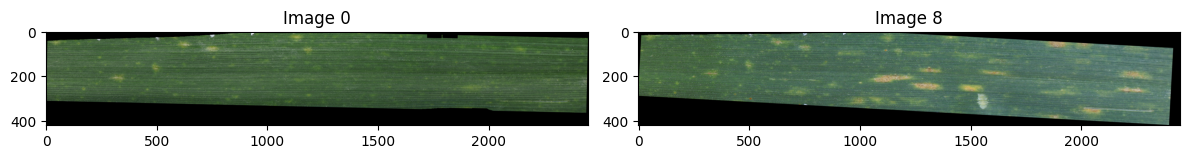

In [4]:
ind = 8
img_fixed, mask_fixed = fetch_image_mask_pair(leaf, 0, img_scale="roi")
img_moving, mask_moving = fetch_image_mask_pair(leaf, ind, img_scale="roi")
img_fixed, img_moving, mask_fixed, mask_moving = match_sizes_resize(img_fixed, img_moving, mask_fixed, mask_moving)
_ = plot_image_pair(img_fixed, img_moving, 0, ind)

Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /home/renku/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt


100%|██████████| 44.2M/44.2M [00:00<00:00, 83.0MB/s]


Total matches: 4984
Matches with Confidence > 0.5: 3009
Inliers: 2024 (40.61%)


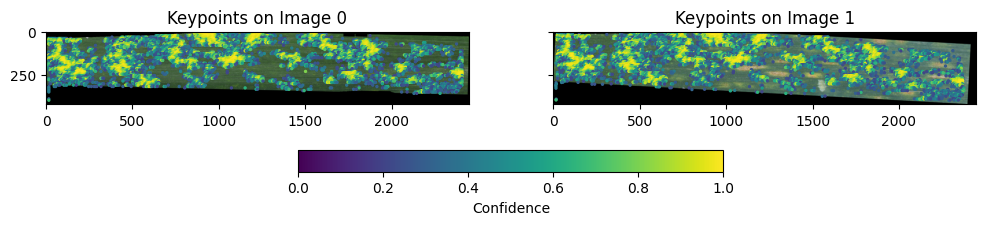

In [5]:
mkpts0, mkpts1, confidence, inliers, n_matches = loftr_match(img_fixed, img_moving, verbose=True, return_n_matches=True)
_ = plot_match_coverage(img_fixed, mkpts0, img_moving, mkpts1, confidence)

## Confidence

In [6]:
def filter_matches_by_confidence_bin_search(mkpts0, mkpts1, confidence, n_target: int=500, tol: int=50, min_conf: float=0.5):
    """
    Filters points by confidence, adjusting the confidence threshold so that the resulting subset of points is within a tolerance of the targeted number of points.
    """
    
    best_0 = mkpts0[confidence > min_conf]
    best_1 = mkpts1[confidence > min_conf]

    if len(best_0) <= n_target:
        return best_0, best_1  # nothing to do

    low = min_conf
    high = 1.0 

    for i in range(20):  # enough iterations to achieve convergence
        mid = (low + high) / 2
        filtered0 = mkpts0[confidence > mid]
        filtered1 = mkpts1[confidence > mid]

        if len(filtered0) > n_target:
            # too many points → increase threshold
            low = mid
        else:
            # too few points → decrease threshold
            high = mid
            best_0 = filtered0
            best_1 = filtered1

        if abs(len(filtered0) - n_target) < tol:
            print("n iter", i)
            print(mid)
            return filtered0, filtered1

    print("not enough iterations")
    print(mid)
    return best_0, best_1

n iter 2
0.9375
Number of Matches: 531


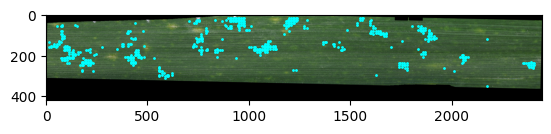

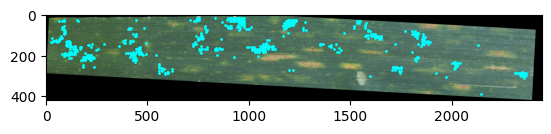

In [7]:
threshold=0.5
tf, tm = filter_matches_by_confidence_bin_search(mkpts0, mkpts1, confidence, n_target=500, tol=50, min_conf=threshold)
print(f"Number of Matches: {tf.shape[0]}")
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(tf[:, 0], tf[:, 1], color='cyan', s=1)
plt.show()
plt.imshow(K.tensor_to_image(img_moving))
plt.scatter(tm[:, 0], tm[:, 1], color='cyan', s=1)
plt.show()

## Grid

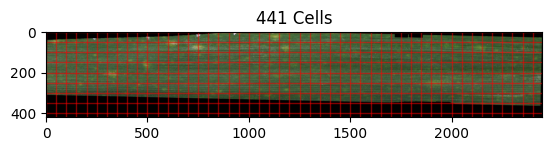

In [8]:
def plot_grid(img, cell_size=40):
    if type(img) == torch.Tensor:
        img = K.tensor_to_image(img)


    height, width = img.shape[:2]

    n_cols = math.ceil(width / cell_size)
    n_rows = math.ceil(height / cell_size)
    total_cells = n_rows * n_cols

    fig, ax = plt.subplots()
    ax.imshow(img)

    # Vertical lines
    for x in range(0, width, cell_size):
        ax.axvline(x=x, color='red', alpha=0.5, linewidth=1)

    # Horizontal lines
    for y in range(0, height, cell_size):
        ax.axhline(y=y, color='red', alpha=0.5, linewidth=1)
    
    ax.set_title(f"{total_cells} Cells")

    # plt.show()
    return fig, ax

fig, ax = plot_grid(img_fixed, 50)
fig.show()

## Spatial Binning based on Grid Cells

In [9]:
# mkpts0[:,0] # x/width
cell_size = 50
W = img_fixed.shape[3]
num_cell_per_row =  math.ceil(W / cell_size)
cell_x = mkpts0[:,0] // cell_size
cell_y = mkpts0[:,1] // cell_size
cell_id = cell_y * num_cell_per_row + cell_x
num_ids = len(cell_id.unique())
cell_id

tensor([ 17.,  17.,  17.,  ..., 388., 343., 343.])

In [10]:
def group_by_argmax(values: torch.Tensor, groups: torch.Tensor):
    """
    Groups the values by group, determines the max for each group and returns the index of those values.

    Args:
        values: Values of which we want to find the max-per-group
        group: Tensor indicating which value belongs to which group

    Returns:
        list of indices of the max value for each group
    """
    # map group ids to consecutive values  0..num_unique-1
    unique_groups, inverse = torch.unique(groups, return_inverse=True)
    num_ids = len(unique_groups)

    # compute max value per group
    max_vals = torch.full((num_ids,), float('-inf'), device=values.device)
    max_vals = max_vals.scatter_reduce(
        0,
        inverse,
        values,
        reduce="amax",
        include_self=True
    )

    # find indices where value is the max
    is_max_mask = (values == max_vals[inverse])

    idx = torch.arange(len(values), device=values.device) # full list of indices
    idx_masked = torch.where(is_max_mask, idx, torch.full_like(idx, -1)) # non-max indices are set to -1

    # filter out indices of max per group
    argmax_idx = torch.full((num_ids,), -1, dtype=torch.long, device=values.device)
    argmax_idx = argmax_idx.scatter_reduce(
        0,
        inverse,
        idx_masked,
        reduce="amax",
        include_self=True
    )
    
    return argmax_idx

In [11]:
points = mkpts0[:20]
values = confidence[:20]
groups = cell_id[:20].long()

print(values)
print(groups)
group_by_argmax(values, groups)

tensor([0.8974, 0.8807, 0.8059, 0.8220, 0.9340, 0.9580, 0.9821, 0.9934, 0.9956,
        0.9987, 0.9995, 0.9845, 0.9938, 0.9962, 0.9951, 0.9721, 0.8844, 0.5092,
        0.3179, 0.5015])
tensor([17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19,
        20, 20])


tensor([ 5, 10, 13, 19])

In [12]:
cell_max_indices = group_by_argmax(confidence, cell_id.long())

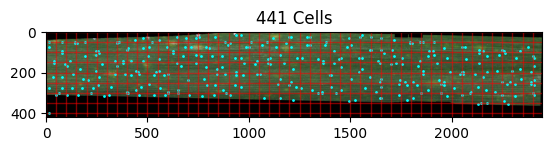

In [13]:
cell_max_coord = mkpts0[cell_max_indices, :]
fig, ax = plot_grid(img_fixed, 50)
ax.scatter(cell_max_coord[:, 0], cell_max_coord[:, 1], color='cyan', s=1)
fig.show()

In [14]:
def filter_matches_by_grid(mkpts0, mkpts1, confidence, img_width, threshold: float=0.5, cell_size: int=50):
    num_cell_per_row =  math.ceil(img_width / cell_size)

    cell_x = mkpts0[:,0] // cell_size
    cell_y = mkpts0[:,1] // cell_size
    cell_id = cell_y * num_cell_per_row + cell_x

    # get indices of max per cell
    cell_max_indices = group_by_argmax(confidence, cell_id.long())

    cell_max_coord0 = mkpts0[cell_max_indices, :]
    cell_max_coord1 = mkpts1[cell_max_indices, :]

    if threshold is not None:
        cell_max_coord0 = cell_max_coord0[confidence[cell_max_indices] > threshold]
        cell_max_coord1 = cell_max_coord1[confidence[cell_max_indices] > threshold]
    return cell_max_coord0, cell_max_coord1

Number of Matches: 277


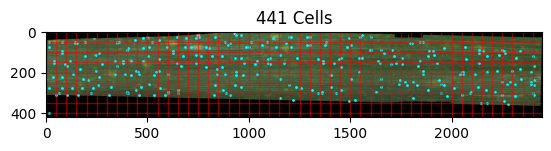

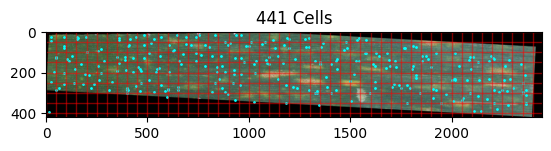

In [15]:
cell_size=50
threshold=0.5
cell_matches_fix, cell_matches_mov = filter_matches_by_grid(mkpts0, mkpts1, confidence, img_width=img_fixed.shape[3], cell_size=cell_size, threshold=threshold)
print(f"Number of Matches: {cell_matches_fix.shape[0]}")
fig, ax = plot_grid(img_fixed, cell_size)
ax.scatter(cell_matches_fix[:, 0], cell_matches_fix[:, 1], color='cyan', s=1)
fig.show()
fig, ax = plot_grid(img_moving, cell_size)
ax.scatter(cell_matches_mov[:, 0], cell_matches_mov[:, 1], color='cyan', s=1) # matches won't be neatly subdivided by cell in moving image anymore, since leaf changes
fig.show()

#### Adaptive

In [16]:
def filter_matches_by_grid_adaptive(mkpts0, mkpts1, confidence, img_shape, n_target: int=500, tol: int=50, threshold: float=0.5, cell_size: int=50):
    """
    Iteratively filters points by min distance, adjusting the min distance parameter so that the resulting subset of points is within a tolerance of the targeted number of points.
    
    Args:
        mkpts0: (N, 2) array/tensor of keypoints in image 0
        mkpts1: (N, 2) array/tensor of keypoints in image 1
        confidence: (N,) match confidence
        img_shape: shape of the underlying image(s)
        n_target: targeted number of matches
        tol: tolerance indicating by how much the number of matches may deviate from the target 
        threshold: confidence threshold. only matches with confidence above this threshold are considered

    Returns:
        filtered kpts0, filtered kpts1
    
    """
    
    best_0 = mkpts0[confidence > threshold]
    best_1 = mkpts1[confidence > threshold]

    if len(best_0) <= n_target:
        return best_0, best_1  # nothing to do

    low = 1e-6  # very small cells → almost all points kept
    high = max(img_shape[-1], img_shape[-2])
    

    for i in range(20):  # enough iterations to achieve convergence
        mid = (low + high) / 2
        filtered0, filtered1 = filter_matches_by_grid(mkpts0, mkpts1, confidence, img_width=img_shape[3], cell_size=mid, threshold=threshold)

        if len(filtered0) > n_target:
            # too many points → increase distance
            low = mid
        else:
            # too few points → decrease distance
            high = mid
            best_0 = filtered0
            best_1 = filtered1

        if abs(len(filtered0) - n_target) < tol:
            print("n iter", i)
            print(mid)
            return filtered0, filtered1

    return best_0, best_1

n iter 8
33.441407236328125
Number of Matches: 473


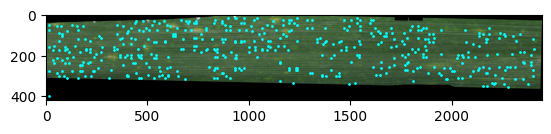

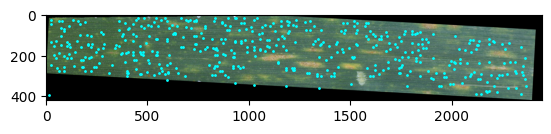

In [17]:
tol = 50
n_target=500
threshold=0.5
cell_matches_fix_ad, cell_matches_mov_ad = filter_matches_by_grid_adaptive(mkpts0, mkpts1, confidence, img_fixed.shape, n_target=n_target, tol=tol, threshold=threshold)
print(f"Number of Matches: {cell_matches_fix_ad.shape[0]}")
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(cell_matches_fix_ad[:, 0], cell_matches_fix_ad[:, 1], color='cyan', s=1)
plt.show()
plt.imshow(K.tensor_to_image(img_moving))
plt.scatter(cell_matches_mov_ad[:, 0], cell_matches_mov_ad[:, 1], color='cyan', s=1)
plt.show()

### TPS Test

Number of Matches: 277


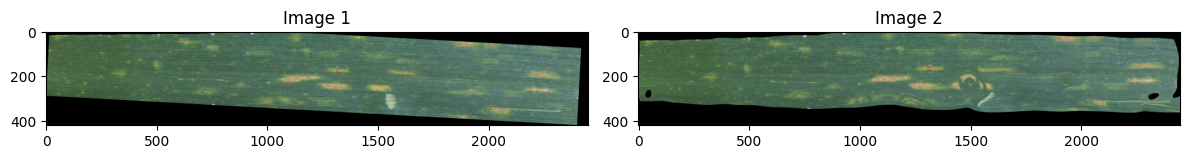

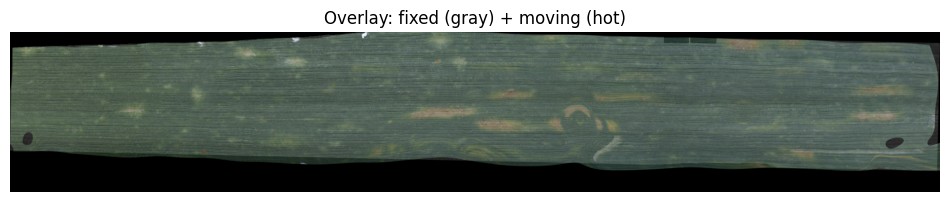

In [18]:
cell_size=50
threshold=0.5
cell_matches_fix, cell_matches_mov = filter_matches_by_grid(mkpts0, mkpts1, confidence, img_width=img_fixed.shape[3], cell_size=cell_size, threshold=threshold)
print(f"Number of Matches: {cell_matches_fix.shape[0]}")
out, _ = tps_skimage(cell_matches_fix, cell_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

Number of Matches: 26


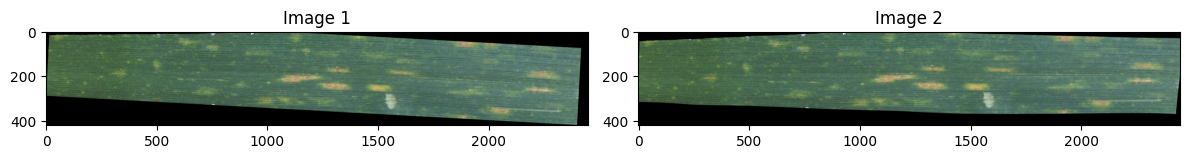

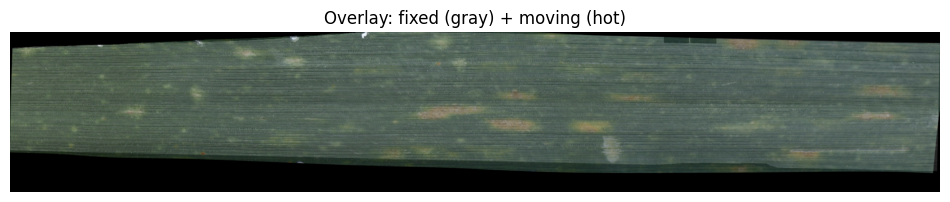

In [19]:
cell_size=200
threshold=0.5
cell_matches_fix, cell_matches_mov = filter_matches_by_grid(mkpts0, mkpts1, confidence, img_width=img_fixed.shape[3], cell_size=cell_size, threshold=threshold)
print(f"Number of Matches: {cell_matches_fix.shape[0]}")
out, _ = tps_skimage(cell_matches_fix, cell_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

Setting threshold..
Threshold set to 0.9463129088000001
Estimating TPS transform...
Transforming moving image...


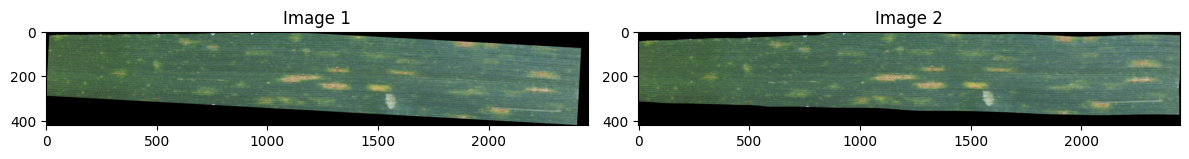

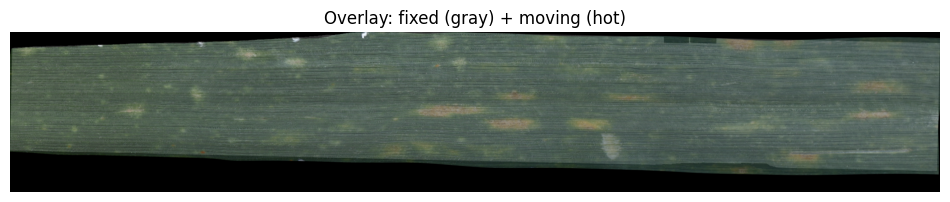

In [20]:
out_og, _ = tps_skimage_confidence(mkpts0, mkpts1, confidence, threshold, img_moving, verbose=True)
_=plot_image_pair(img_moving, out_og)
_=plot_overlay(img_fixed, out_og)

## K-Means Clustering

In [21]:
threshold = 0.5
mkpts0_th = mkpts0[confidence > threshold]
mkpts1_th = mkpts1[confidence > threshold]

In [22]:
from sklearn.cluster import KMeans
n_clusters = 400
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(mkpts0_th)
kmeans.labels_[:10]

array([275, 275, 275, 275, 153, 153, 153, 385, 385, 385], dtype=int32)

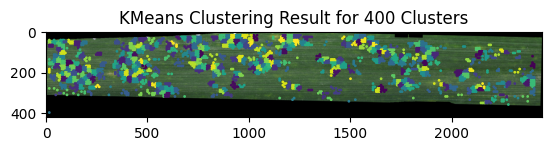

In [23]:
# Plot data points colored by cluster
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(mkpts0_th[:, 0], mkpts0_th[:, 1], c=kmeans.labels_, s=1)

plt.title(f"KMeans Clustering Result for {n_clusters} Clusters")
plt.show()

### Pick highest confidence per cluster

In [24]:
vals = confidence[:20]
grps = torch.Tensor(kmeans.labels_[:20])
print(vals)
print(grps)

group_by_argmax(vals, grps)

tensor([0.8974, 0.8807, 0.8059, 0.8220, 0.9340, 0.9580, 0.9821, 0.9934, 0.9956,
        0.9987, 0.9995, 0.9845, 0.9938, 0.9962, 0.9951, 0.9721, 0.8844, 0.5092,
        0.3179, 0.5015])
tensor([275., 275., 275., 275., 153., 153., 153., 385., 385., 385., 198., 198.,
        198., 198., 379., 379., 379., 379., 367., 367.])


tensor([ 6, 10,  0, 19, 14,  9])

Number of Matches: 400


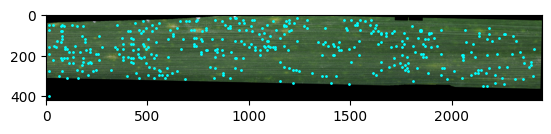

In [25]:
idx = group_by_argmax(confidence[confidence>threshold], torch.Tensor(kmeans.labels_))
cluster_max_coord = mkpts0_th[idx, :]
print(f"Number of Matches: {cluster_max_coord.shape[0]}")
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(cluster_max_coord[:, 0], cluster_max_coord[:, 1], color='cyan', s=1)
plt.show()

In [26]:
def filter_matches_by_cluster(mkpts0, mkpts1, confidence, threshold: float=0.5, n_clusters: int=400):

    # only consider above threshold
    mkpts0_th = mkpts0[confidence > threshold]
    mkpts1_th = mkpts1[confidence > threshold]

    # cluster remaining matches
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(mkpts0_th)
    
    # get indices of max per cell
    cluster_max_indices = group_by_argmax(confidence[confidence>threshold], torch.Tensor(kmeans.labels_))
    cluster_max_coord0 = mkpts0_th[cluster_max_indices, :]
    cluster_max_coord1 = mkpts1_th[cluster_max_indices, :]

    return cluster_max_coord0, cluster_max_coord1

Number of Matches: 50


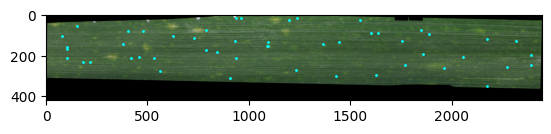

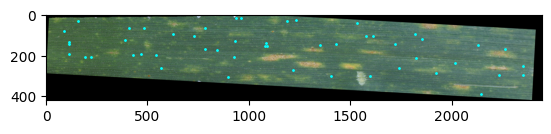

In [27]:
# n_clusters=400
n_clusters=50
threshold=0.5
cluster_matches_fix, cluster_matches_mov = filter_matches_by_cluster(mkpts0, mkpts1, confidence, n_clusters=n_clusters, threshold=threshold)
print(f"Number of Matches: {cluster_matches_fix.shape[0]}")
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(cluster_matches_fix[:, 0], cluster_matches_fix[:, 1], color='cyan', s=1)
plt.show()
plt.imshow(K.tensor_to_image(img_moving))
plt.scatter(cluster_matches_mov[:, 0], cluster_matches_mov[:, 1], color='cyan', s=1)
plt.show()

### TPS Test

Number of Matches: 400


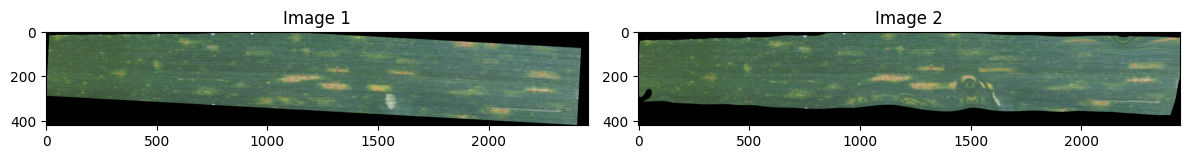

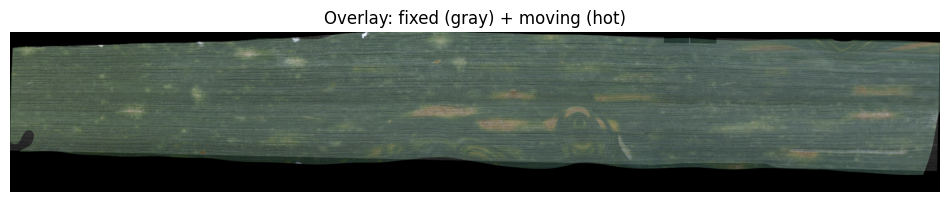

In [28]:
n_clusters=400
threshold=0.5
cluster_matches_fix, cluster_matches_mov = filter_matches_by_cluster(mkpts0, mkpts1, confidence, n_clusters=n_clusters, threshold=threshold)
print(f"Number of Matches: {cluster_matches_fix.shape[0]}")
out, _ = tps_skimage(cluster_matches_fix, cluster_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

Number of Matches: 50


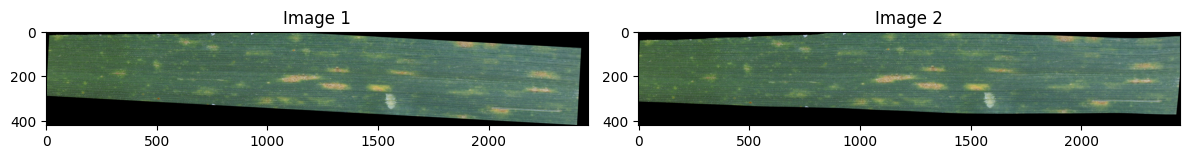

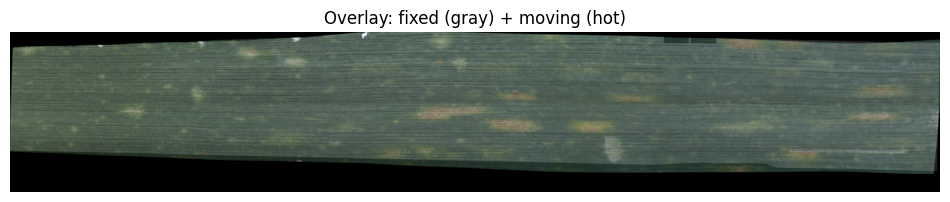

In [29]:
n_clusters=50
threshold=0.5
cluster_matches_fix, cluster_matches_mov = filter_matches_by_cluster(mkpts0, mkpts1, confidence, n_clusters=n_clusters, threshold=threshold)
print(f"Number of Matches: {cluster_matches_fix.shape[0]}")
out, _ = tps_skimage(cluster_matches_fix, cluster_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

Setting threshold..
Threshold set to 0.9463129088000001
Estimating TPS transform...
Transforming moving image...


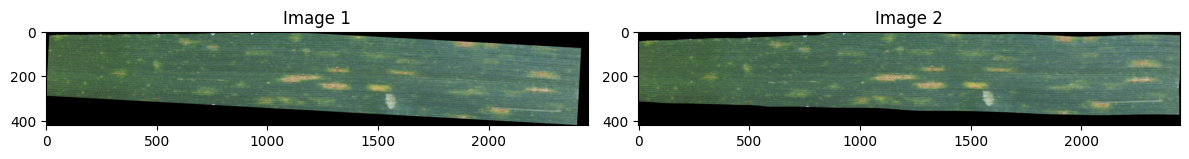

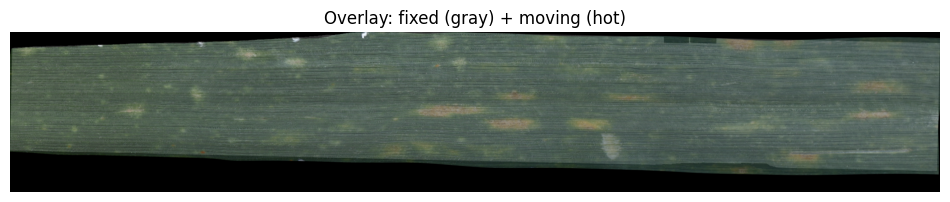

In [30]:
out_og, _ = tps_skimage_confidence(mkpts0, mkpts1, confidence, threshold, img_moving, verbose=True)
_=plot_image_pair(img_moving, out_og)
_=plot_overlay(img_fixed, out_og)

## Enforcing Minimum Distance

Number of Matches: 96


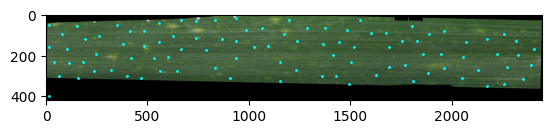

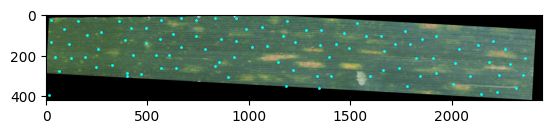

In [31]:
min_dist = 70
max_points=None
threshold=0.5
dist_matches_fix, dist_matches_mov = filter_matches_by_min_distance(mkpts0, mkpts1, confidence, min_dist=min_dist, max_points=max_points, threshold=threshold)
print(f"Number of Matches: {dist_matches_fix.shape[0]}")
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(dist_matches_fix[:, 0], dist_matches_fix[:, 1], color='cyan', s=1)
plt.show()
plt.imshow(K.tensor_to_image(img_moving))
plt.scatter(dist_matches_mov[:, 0], dist_matches_mov[:, 1], color='cyan', s=1)
plt.show()

#### Adaptive

In [32]:
def filter_matches_by_min_distance_adaptive(mkpts0, mkpts1, confidence, img_shape, n_target: int=500, tol: int=50, max_points: int=500, threshold: float=0.5):
    """
    Iteratively filters points by min distance, adjusting the min distance parameter so that the resulting subset of points is within a tolerance of the targeted number of points.
    """
    
    if len(mkpts0) <= n_target:
        return mkpts0, mkpts1  # nothing to do

    low = 0.0
    high = np.sqrt(img_shape[-1]**2 + img_shape[-2]**2)  # e.g. image diagonal
    

    best_0 = mkpts0
    best_1 = mkpts1

    for i in range(20):  # enough iterations to achieve convergence
        mid = (low + high) / 2
        filtered0, filtered1 = filter_matches_by_min_distance(mkpts0, mkpts1, confidence, min_dist=mid, max_points=max_points, threshold=threshold)

        if len(filtered0) > n_target:
            # too many points → increase distance
            low = mid
        else:
            # too few points → decrease distance
            high = mid
            best_0 = filtered0
            best_1 = filtered1

        if abs(len(filtered0) - n_target) < tol:
            return filtered0, filtered1

    return best_0, best_1

Number of Matches: 184


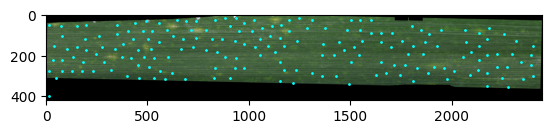

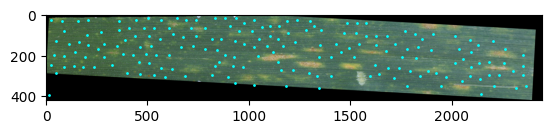

In [33]:
tol = 20
n_target=200
threshold=0.5
dist_matches_fix_ad, dist_matches_mov_ad = filter_matches_by_min_distance_adaptive(mkpts0, mkpts1, confidence, img_fixed.shape, n_target=n_target, tol=tol, threshold=threshold)
print(f"Number of Matches: {dist_matches_fix_ad.shape[0]}")
plt.imshow(K.tensor_to_image(img_fixed))
plt.scatter(dist_matches_fix_ad[:, 0], dist_matches_fix_ad[:, 1], color='cyan', s=1)
plt.show()
plt.imshow(K.tensor_to_image(img_moving))
plt.scatter(dist_matches_mov_ad[:, 0], dist_matches_mov_ad[:, 1], color='cyan', s=1)
plt.show()

### TPS Test

Number of Matches: 496


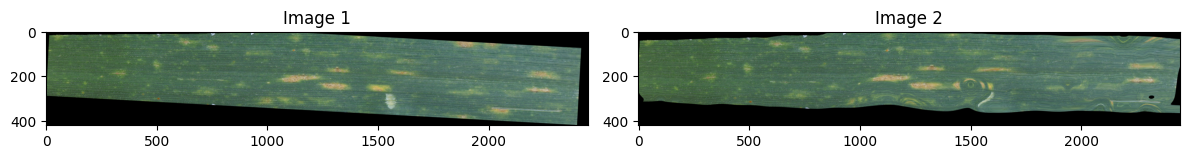

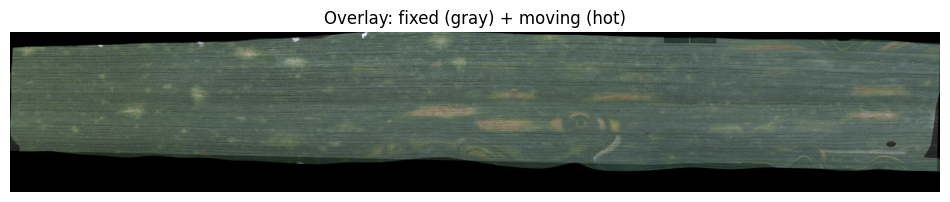

In [34]:
min_dist = 20
max_points=None
threshold=0.5
dist_matches_fix, dist_matches_mov = filter_matches_by_min_distance(mkpts0, mkpts1, confidence, min_dist=min_dist, max_points=max_points, threshold=threshold)
print(f"Number of Matches: {dist_matches_fix.shape[0]}")
out, _ = tps_skimage(dist_matches_fix, dist_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

Number of Matches: 76


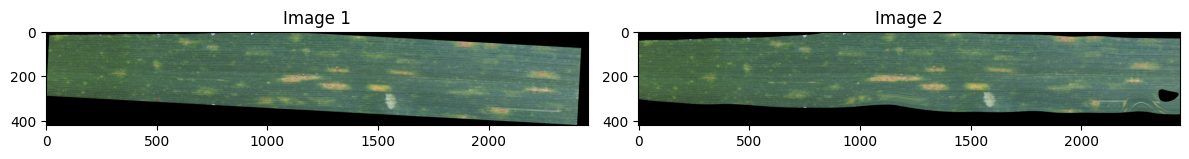

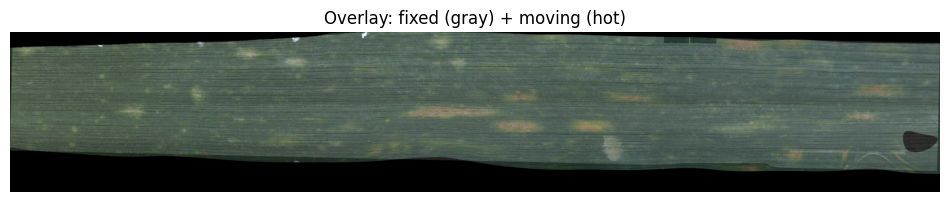

In [35]:
min_dist = 80
max_points=None
threshold=0.5
dist_matches_fix, dist_matches_mov = filter_matches_by_min_distance(mkpts0, mkpts1, confidence, min_dist=min_dist, max_points=max_points, threshold=threshold)
print(f"Number of Matches: {dist_matches_fix.shape[0]}")
out, _ = tps_skimage(dist_matches_fix, dist_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)

Setting threshold..
Threshold set to 0.9463129088000001
Estimating TPS transform...
Transforming moving image...


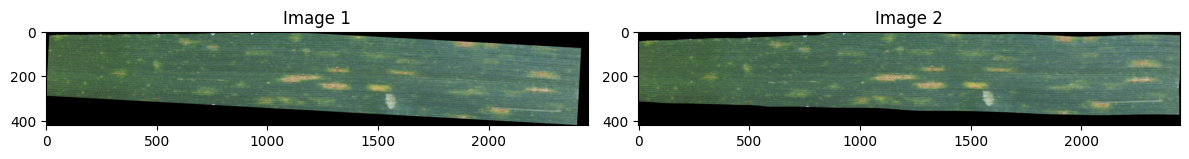

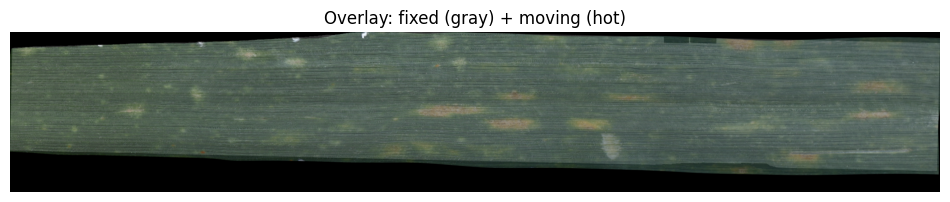

In [36]:
out_og, _ = tps_skimage_confidence(mkpts0, mkpts1, confidence, threshold, img_moving, verbose=True)
_=plot_image_pair(img_moving, out_og)
_=plot_overlay(img_fixed, out_og)

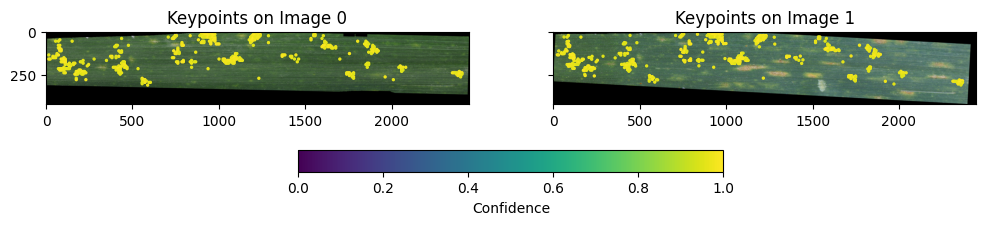

In [37]:
# landmark distribution after auto-thresholding
auto_threshold = 0.9463129088000001
_ = plot_match_coverage(img_fixed, mkpts0[confidence>auto_threshold], img_moving, mkpts1[confidence>auto_threshold], confidence[confidence>auto_threshold])

### Other Leaf

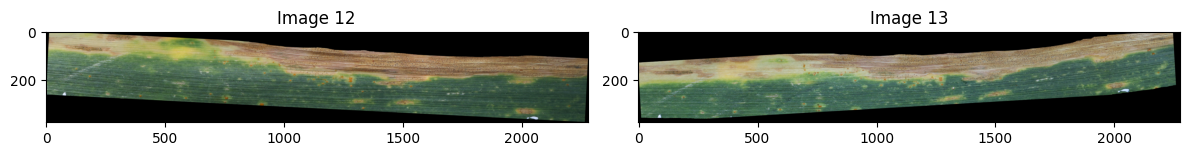

In [38]:
ind_fix = 12
ind_mov = 13
img_fixed, mask_fixed = fetch_image_mask_pair(leaf2, ind_fix, img_scale="roi")
img_moving, mask_moving = fetch_image_mask_pair(leaf2, ind_mov, img_scale="roi")
img_fixed, img_moving, mask_fixed, mask_moving = match_sizes_resize(img_fixed, img_moving, mask_fixed, mask_moving)
_ = plot_image_pair(img_fixed, img_moving, ind_fix, ind_mov)

Total matches: 4658
Matches with Confidence > 0.5: 3076
Inliers: 1731 (37.16%)


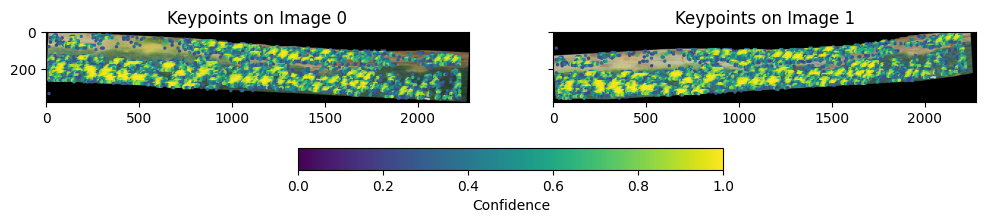

In [39]:

mkpts0, mkpts1, confidence, inliers, n_matches = loftr_match(img_fixed, img_moving, verbose=True, return_n_matches=True)
_ = plot_match_coverage(img_fixed, mkpts0, img_moving, mkpts1, confidence)

Number of Matches: 62


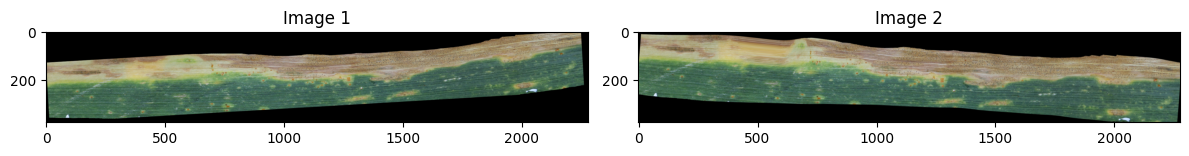

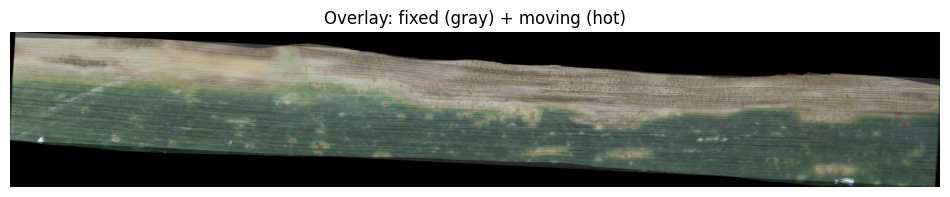

In [40]:
min_dist = 80
max_points=None
threshold=0.5
dist_matches_fix, dist_matches_mov = filter_matches_by_min_distance(mkpts0, mkpts1, confidence, min_dist=min_dist, max_points=max_points, threshold=threshold)
print(f"Number of Matches: {dist_matches_fix.shape[0]}")
out, _ = tps_skimage(dist_matches_fix, dist_matches_mov, img_mov=img_moving)
_=plot_image_pair(img_moving, out)
_=plot_overlay(img_fixed, out)